In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mathurutkarsh/zomato-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mathurutkarsh/zomato-dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
import pandas as pd

file_path = "/kaggle/input/datasets/mathurutkarsh/zomato-dataset/zomato.csv"

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    low_memory=False
)

print("Dataset loaded successfully.")
print("Dataset size:", df.shape)


Dataset loaded successfully.
Dataset size: (9551, 21)


In [8]:
print("Number of rows and columns:", df.shape)

df.head()

Number of rows and columns: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [10]:
print("Column names:")

print(df.columns.tolist())

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [13]:
print("Missing values:")

print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Duplicate rows: 0


In [15]:
df = df.rename(columns={
    "Restaurant ID": "restaurant_id",
    "Restaurant Name": "restaurant_name",
    "Country Code": "country_code",
    "City": "city",
    "Address": "address",
    "Locality": "locality",
    "Cuisines": "cuisines",
    "Average Cost for two": "average_cost",
    "Has Table booking": "table_booking",
    "Has Online delivery": "online_delivery",
    "Price range": "price_range",
    "Aggregate rating": "rating",
    "Rating text": "rating_text",
    "Votes": "votes"
})

print("Columns renamed successfully.")

print(df.columns.tolist())

Columns renamed successfully.
['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address', 'locality', 'Locality Verbose', 'Longitude', 'Latitude', 'cuisines', 'average_cost', 'Currency', 'table_booking', 'online_delivery', 'Is delivering now', 'Switch to order menu', 'price_range', 'rating', 'Rating color', 'rating_text', 'votes']


In [16]:
data = df.copy()

rows_before = len(data)

# Remove exact duplicate rows
data = data.drop_duplicates()

# Remove duplicate restaurant IDs
data = data.drop_duplicates(
    subset="restaurant_id"
)

# Remove rows with missing important information
data = data.dropna(
    subset=[
        "restaurant_name",
        "city",
        "cuisines",
        "rating",
        "votes",
        "price_range",
        "online_delivery"
    ]
)

# Remove extra spaces from text columns
data["restaurant_name"] = (
    data["restaurant_name"].str.strip()
)

data["city"] = data["city"].str.strip()
data["cuisines"] = data["cuisines"].str.strip()

print("Rows before cleaning:", rows_before)
print("Rows after cleaning:", len(data))
print("Rows removed:", rows_before - len(data))

data.head()

Rows before cleaning: 9551
Rows after cleaning: 9542
Rows removed: 9


,restaurant_id,restaurant_name,country_code,city,address,locality,Locality Verbose,Longitude,Latitude,cuisines,...,Currency,table_booking,online_delivery,Is delivering now,Switch to order menu,price_range,rating,Rating color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [17]:
data[
    ["average_cost", "price_range", "rating", "votes"]
].describe()

,average_cost,price_range,rating,votes
count,9542.000000,9542.000000,9542.000000,9542.000000
mean,1200.326137,1.804968,2.665238,156.772060
std,16128.743876,0.905563,1.516588,430.203324
min,0.000000,1.000000,0.000000,0.000000
25%,250.000000,1.000000,2.500000,5.000000
50%,400.000000,2.000000,3.200000,31.000000
75%,700.000000,2.000000,3.700000,130.000000
max,800000.000000,4.000000,4.900000,10934.000000


In [18]:
city_counts = data["city"].value_counts()

top_city = city_counts.index[0]
top_city_count = city_counts.iloc[0]

print("City with the most restaurants:", top_city)
print("Number of restaurants:", top_city_count)

city_counts.head(10)

City with the most restaurants: New Delhi
Number of restaurants: 5473


city
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64

In [19]:
cuisine_counts = (
    data["cuisines"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
)

top_cuisine = cuisine_counts.index[0]
top_cuisine_count = cuisine_counts.iloc[0]

print("Most common cuisine:", top_cuisine)
print("Number of restaurants:", top_cuisine_count)

cuisine_counts.head(10)

Most common cuisine: North Indian
Number of restaurants: 3960


cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

In [20]:
rated_data = data[
    data["rating"] > 0
].copy()

average_rating = rated_data["rating"].mean()

print(
    "Average customer rating:",
    round(average_rating, 2),
    "out of 5"
)

Average customer rating: 3.44 out of 5


In [21]:
city_rating = (
    rated_data.groupby("city")
    .agg(
        average_rating=("rating", "mean"),
        restaurant_count=("restaurant_id", "count")
    )
)

# Use only cities containing at least 20 rated restaurants
city_rating = city_rating[
    city_rating["restaurant_count"] >= 20
]

city_rating = city_rating.sort_values(
    by="average_rating",
    ascending=False
)

best_city = city_rating.index[0]

best_city_rating = city_rating.iloc[0][
    "average_rating"
]

print("City with the highest average rating:", best_city)

print(
    "Average rating:",
    round(best_city_rating, 2)
)

city_rating.head(10)

City with the highest average rating: London
Average rating: 4.54


,average_rating,restaurant_count
city,,
London,4.535,20
Tampa Bay,4.410,20
Bangalore,4.375,20
Dubai,4.370,20
Chennai,4.315,20
Ankara,4.305,20
Abu Dhabi,4.300,20
Auckland,4.275,20
Boise,4.260,20


In [22]:
online_counts = (
    data["online_delivery"].value_counts()
)

online_percentage = (
    data["online_delivery"]
    .value_counts(normalize=True) * 100
)

online_yes = online_percentage.get("Yes", 0)

print("Online delivery count:")

print(online_counts)

print("\nOnline delivery percentage:")

print(online_percentage.round(2))

print(
    "\nRestaurants providing online delivery:",
    round(online_yes, 2),
    "%"
)

Online delivery count:
online_delivery
No     7091
Yes    2451
Name: count, dtype: int64

Online delivery percentage:
online_delivery
No     74.31
Yes    25.69
Name: proportion, dtype: float64

Restaurants providing online delivery: 25.69 %


In [23]:
top_voted_restaurants = (
    data[
        [
            "restaurant_name",
            "city",
            "rating",
            "votes"
        ]
    ]
    .sort_values(
        by="votes",
        ascending=False
    )
    .head(10)
)

top_restaurant = (
    top_voted_restaurants.iloc[0][
        "restaurant_name"
    ]
)

highest_votes = (
    top_voted_restaurants.iloc[0]["votes"]
)

print(
    "Restaurant with the highest votes:",
    top_restaurant
)

print(
    "Number of votes:",
    int(highest_votes)
)

top_voted_restaurants

Restaurant with the highest votes: Toit
Number of votes: 10934


,restaurant_name,city,rating,votes
728,Toit,Bangalore,4.8,10934
735,Truffles,Bangalore,4.7,9667
3994,Hauz Khas Social,New Delhi,4.3,7931
2412,Peter Cat,Kolkata,4.3,7574
739,AB's - Absolute Barbecues,Bangalore,4.6,6907
2414,Barbeque Nation,Kolkata,4.9,5966
743,Big Brewsky,Bangalore,4.5,5705
2307,AB's - Absolute Barbecues,Hyderabad,4.9,5434
736,The Black Pearl,Bangalore,4.1,5385
2411,BarBQ,Kolkata,4.2,5288


In [24]:
price_names = {
    1: "Range 1 - Lowest",
    2: "Range 2 - Medium",
    3: "Range 3 - High",
    4: "Range 4 - Highest"
}

data["price_category"] = (
    data["price_range"].map(price_names)
)

price_counts = (
    data["price_category"].value_counts()
)

common_price = price_counts.index[0]
common_price_count = price_counts.iloc[0]

print("Most common price range:", common_price)

print(
    "Number of restaurants:",
    common_price_count
)

price_counts

Most common price range: Range 1 - Lowest
Number of restaurants: 4438


price_category
Range 1 - Lowest     4438
Range 2 - Medium     3113
Range 3 - High       1405
Range 4 - Highest     586
Name: count, dtype: int64

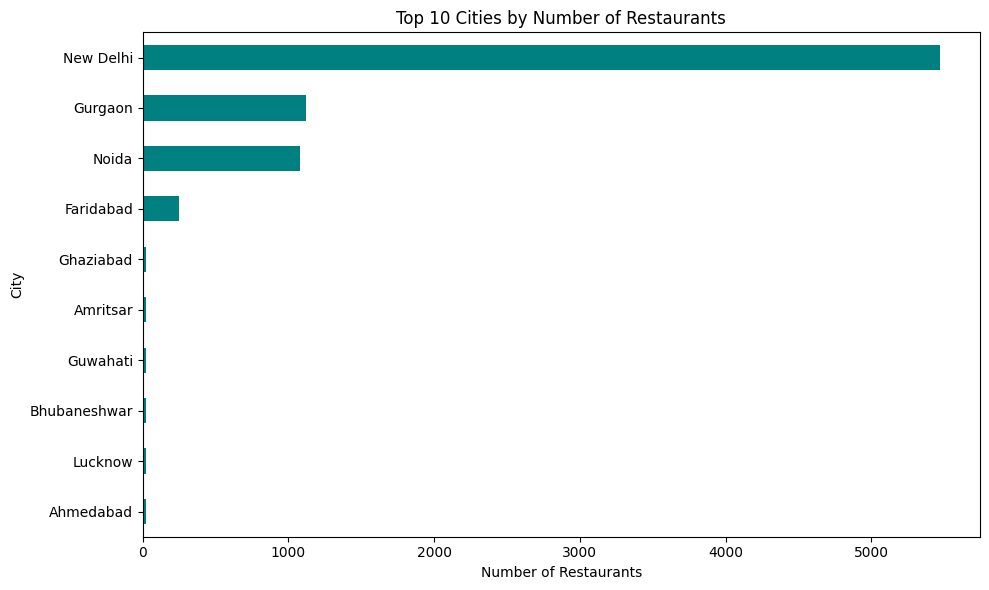

In [25]:
top_cities = (
    city_counts.head(10).sort_values()
)

plt.figure(figsize=(10, 6))

top_cities.plot(
    kind="barh",
    color="teal"
)

plt.title(
    "Top 10 Cities by Number of Restaurants"
)

plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

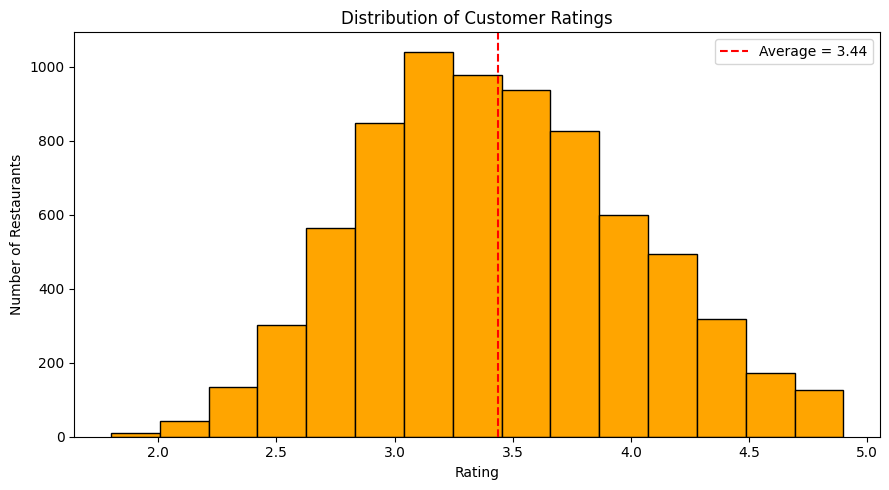

In [26]:
plt.figure(figsize=(9, 5))

plt.hist(
    rated_data["rating"],
    bins=15,
    color="orange",
    edgecolor="black"
)

plt.axvline(
    average_rating,
    color="red",
    linestyle="--",
    label=f"Average = {average_rating:.2f}"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.legend()
plt.tight_layout()
plt.show()

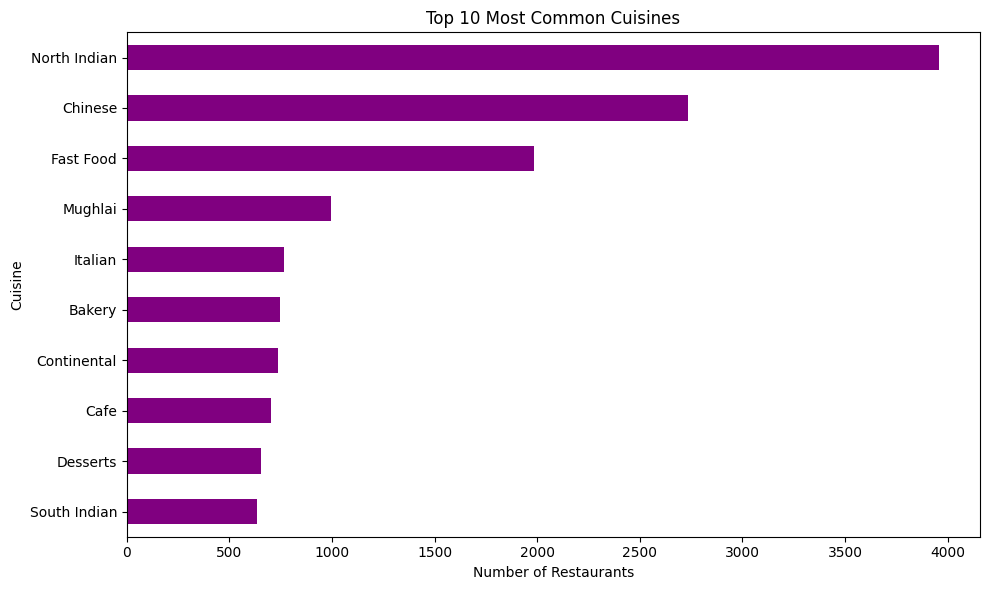

In [27]:
top_cuisines = (
    cuisine_counts.head(10).sort_values()
)

plt.figure(figsize=(10, 6))

top_cuisines.plot(
    kind="barh",
    color="purple"
)

plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

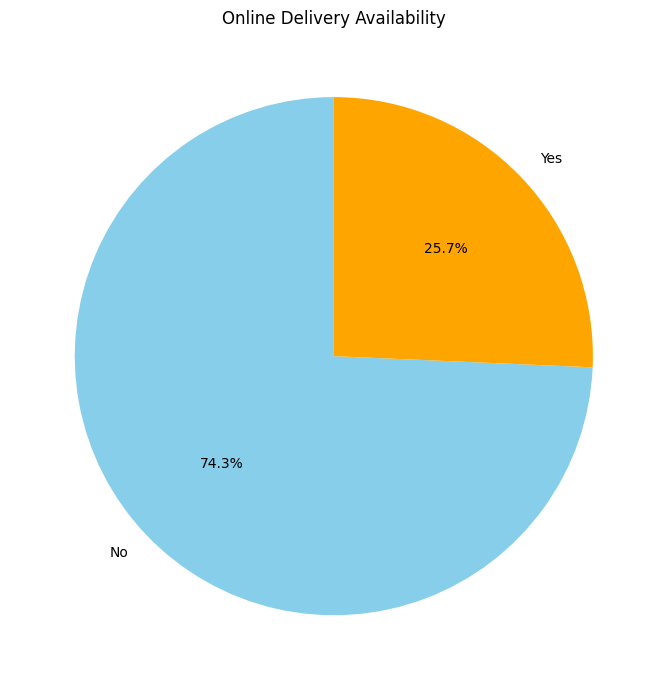

In [28]:
plt.figure(figsize=(7, 7))

online_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue", "orange"],
    startangle=90
)

plt.title("Online Delivery Availability")
plt.ylabel("")

plt.tight_layout()
plt.show()

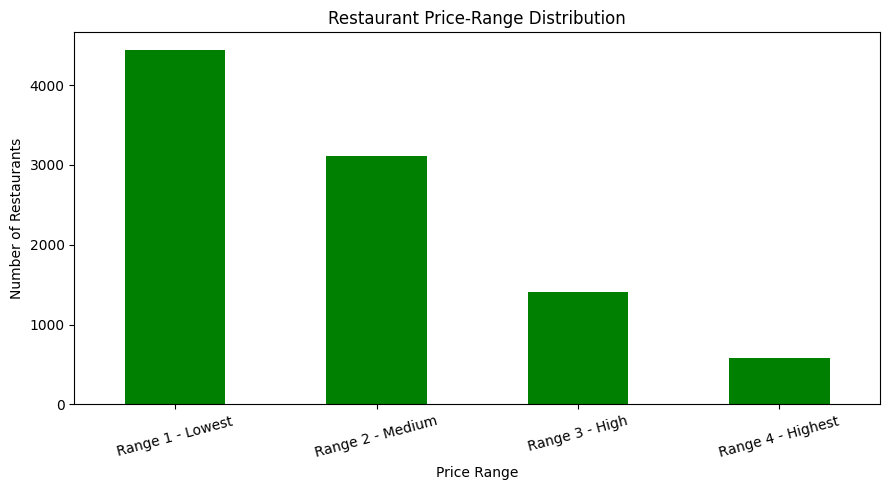

In [29]:
ordered_prices = [
    "Range 1 - Lowest",
    "Range 2 - Medium",
    "Range 3 - High",
    "Range 4 - Highest"
]

price_chart_data = (
    data["price_category"]
    .value_counts()
    .reindex(ordered_prices)
)

plt.figure(figsize=(9, 5))

price_chart_data.plot(
    kind="bar",
    color="green"
)

plt.title("Restaurant Price-Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [30]:
print("CONCLUSION\n")

print(
    f"{top_city} has the highest number of restaurants, "
    f"with {top_city_count} restaurants."
)

print(
    f"{top_cuisine} is the most common cuisine, "
    f"and the average customer rating is "
    f"{average_rating:.2f} out of 5."
)

print(
    f"Among cities with at least 20 rated restaurants, "
    f"{best_city} has the highest average rating of "
    f"{best_city_rating:.2f}."
)

print(
    f"{online_yes:.2f}% of restaurants provide online "
    f"delivery, and {common_price} is the most common "
    f"price category."
)

print(
    f"{top_restaurant} received the highest number "
    f"of customer votes."
)

CONCLUSION

New Delhi has the highest number of restaurants, with 5473 restaurants.
North Indian is the most common cuisine, and the average customer rating is 3.44 out of 5.
Among cities with at least 20 rated restaurants, London has the highest average rating of 4.54.
25.69% of restaurants provide online delivery, and Range 1 - Lowest is the most common price category.
Toit received the highest number of customer votes.
